In [1]:
import sys
sys.path.append("/home/getuanhui/project/finnal_exp")
from utils.visualizations import plot_top_down_map , images_to_video_with_audio , combine_all_audio_data
from PIL import Image
import pickle , os
import numpy as np

/home/getuanhui/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
path = '../dataset-data3/dataset/pickle/hybird(heard_train_multiple)/1LXtFkjw3qL/55.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)

In [14]:
data.keys()

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id', 'greedy_action', 'total_sound_point'])

In [18]:
data['action_id']

[[2, 1, 3, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 2, 1, 0]]

In [11]:
data['info'][-1]

{'distance_to_goal': 0.0,
 'normalized_distance_to_goal': 0.0,
 'success': 1.0,
 'spl': 0.2,
 'softspl': 0.2,
 'na': 71,
 'sna': 0.1267605633802817,
 'top_down_map': {'map': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'fog_of_war_mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'agent_map_coord': (797, 122),
  'agent_angle': 6.283185307179586}}

In [6]:
data['action_id']

[3,
 2,
 3,
 3,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 3,
 3,
 1,
 2,
 2,
 1,
 3,
 3,
 1,
 2,
 2,
 1,
 3,
 3,
 1,
 2,
 2,
 1,
 3,
 3,
 1,
 2,
 3,
 2,
 2,
 2,
 2,
 3,
 1,
 1,
 3,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 3,
 2,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 0]

In [42]:
len(data['collision'])

174

In [5]:
print(data.keys())
print(data['obs'][0].keys())

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id', 'greedy_action', 'total_sound_point'])
dict_keys(['rgb', 'depth', 'spectrogram', 'angle'])


In [6]:
print(f"reward : {len(data['reward'])} , done {len(data['done'])} , obs {len(data['obs'])} , action {len(data['action_id'])}")

reward : 23 , done 23 , obs 24 , action 1


In [7]:
data['done']

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 False,
 True]

In [8]:
data['total_sound_point']

[]

In [9]:
data['action_id']

[[3, 3, 1, 2, 1, 3, 1, 1, 1, 2, 1, 3, 1, 1, 1, 3, 1, 1, 1, 3, 1, 1, 0]]

In [10]:
data['reward']

[-0.01,
 -0.01,
 0.99,
 -0.01,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 9.99]

### draw depth

(-0.5, 127.5, 127.5, -0.5)

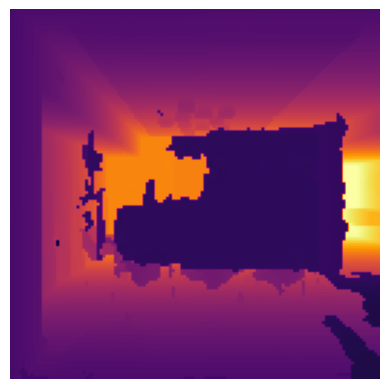

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# assume depth is your (128,128,1) array
depth_2d = np.squeeze(data['obs'][0]['depth'])  # becomes (128,128)

plt.imshow(depth_2d, cmap='inferno')
plt.axis('off')


### draw obs

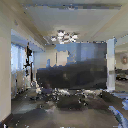

In [12]:
Image.fromarray(data['obs'][0]['rgb'])

### draw map

In [13]:
len(data['action_id'])

1

In [34]:
data['reward']

[-0.01,
 0.99,
 0.99,
 -0.01,
 -1.01,
 -0.01,
 -1.01,
 -1.01,
 -0.01,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 -0.01,
 0.99,
 0.99,
 0.99,
 0.99,
 0.99,
 -0.01,
 0.99,
 9.99]

In [35]:
data['action_id']

[2, 1, 1, 2, 1, 3, 1, 1, 3, 3, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 0]

In [36]:
data['info'][-1]

{'distance_to_goal': 0.0,
 'normalized_distance_to_goal': 0.0,
 'success': 1.0,
 'spl': 0.5999765691370905,
 'softspl': 0.5999765691370905,
 'na': 24,
 'sna': 0.5833333333333334,
 'top_down_map': {'map': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'fog_of_war_mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'agent_map_coord': (188, 379),
  'agent_angle': 3.141592653589793}}

In [37]:
import pickle
from PIL import Image
# path = '../dataset/pickle/v2/offline(version5)/qoiz87JEwZ2/3658.pkl'
# with open(path , 'rb') as f:
#     data = pickle.load(f)
Image.fromarray(data['map'][0]).save('./noise.png')

In [2]:
import os
path = '../dataset/pickle/v2/offline(version_final_1.5)/level3'
scenes = [os.path.join(path , i) for i in os.listdir(path)]
files = []
for s in scenes:
    files.extend([os.path.join(s , i) for i in os.listdir(s)])

In [7]:
import pickle
from PIL import Image
# path = '../dataset/pickle/v2/offline(version4)/level3/8WUmhLawc2A/1480.pkl'
# path = '../dataset/pickle/v2/greedy(hybirdnetwork_with_RGBD_train)/2n8kARJN3HM/44081.pkl'
os.makedirs("../test_img_2.0" , exist_ok=True)
for index , file in enumerate(files):
    print(file)
    with open(file , 'rb') as f:
        data = pickle.load(f)
        os.makedirs(f"../test_img_2.0/{file.split('/')[6]}" , exist_ok=True)
    Image.fromarray(data['map'][0]).save(f"../test_img_2.0/{file.split('/')[6]}/{file.split('/')[7][:-4]}.png")

../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/111.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/498.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5976.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5280.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/9819.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/9046.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/6849.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/5126.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/4.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/4006.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/3145.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/7595.pkl
../dataset/pickle/v2/offline(version_final_1.5)/level3/b8cTxDM8gDG/3946.pkl
../dataset/pickle

In [57]:
path = '../dataset/pickle/v2/offline(version7)/level3/qoiz87JEwZ2/4418.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)


In [46]:
data['info'][-3]

{'distance_to_goal': 10.0,
 'normalized_distance_to_goal': 0.24390243902439024,
 'success': 0.0,
 'spl': 0.0,
 'softspl': 0.2561979202882483,
 'na': 172,
 'sna': 0.0,
 'top_down_map': {'map': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'fog_of_war_mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'agent_map_coord': (179, 601),
  'agent_angle': 1.5707963267948966}}

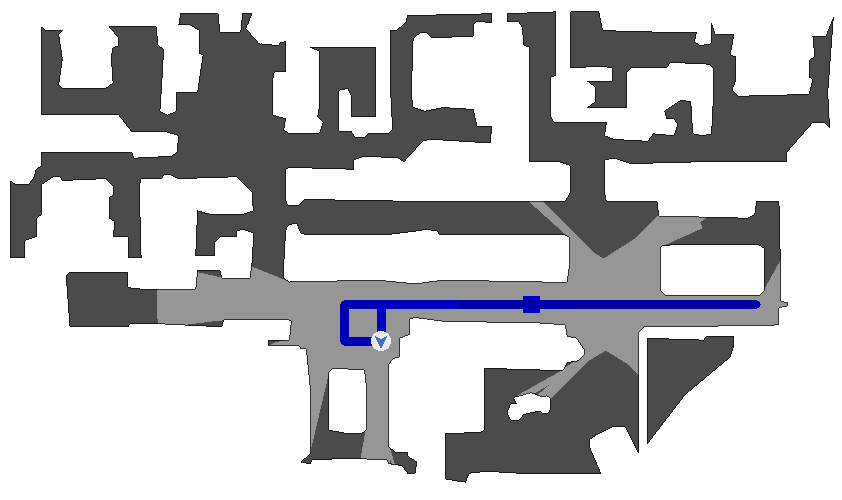

In [50]:
Image.fromarray(plot_top_down_map(data['info'][-1]))

### draw video

In [39]:
img = []
for i in data['info']:
    img.append(np.array(Image.fromarray(plot_top_down_map(i))))
images_to_video(images=img , output_dir='./' , video_name='version1_1' , fps=1)

2025-11-08 20:04:16,067 Video created: ./version1_1.mp4
100%|██████████| 24/24 [00:00<00:00, 553.32it/s]


In [43]:
img = []
for i in data['obs']:
    img.append(np.array(Image.fromarray(i['rgb'])))
images_to_video(images=img , output_dir='./' , video_name='version1_2' , fps=0.1)

2025-11-08 20:09:46,812 Video created: ./version1_2.mp4
100%|██████████| 25/25 [00:00<00:00, 926.13it/s]


### draw audio

In [22]:
combine_all_audio_data(data)

开始处理 14 个音频片段...
片段 0: 有声音 (最大值: 1.82e-01)
片段 1: 有声音 (最大值: 2.68e-01)
片段 2: 有声音 (最大值: 1.89e-01)
片段 3: 有声音 (最大值: 1.76e-01)
片段 4: 有声音 (最大值: 2.37e-01)
片段 5: 有声音 (最大值: 1.78e-01)
片段 6: 有声音 (最大值: 1.86e-01)
片段 7: 有声音 (最大值: 2.62e-01)
片段 8: 有声音 (最大值: 3.01e-01)
片段 9: 有声音 (最大值: 4.04e-01)
片段 10: 有声音 (最大值: 4.39e-01)
片段 11: 有声音 (最大值: 2.85e-01)
片段 12: 有声音 (最大值: 1.44e+00)
片段 13: 有声音 (最大值: 1.44e+00)
正在合并音频片段...
✅ 所有音频已合并保存至：combined_audio.wav
合并后音频形状：(224000, 2)
总时长：14.00 秒
